## 统计分析

通过指定统计分析字段，得到每个特征的p_value，所有的p_value计算都是基于Ttest计算。支持指定不同的分组`group`，例如train、val、test等分组统计。

对于两大类不同的特征

1. 离散特征，统计数量以及占比。
2. 连续特征，统计均值、方差。

In [1]:
import pandas as pd
import os
import numpy as np
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info

task = get_param_in_cwd('task_column') or 'label'
p_value = get_param_in_cwd('p_value') or 0.05
# 修改成自己临床数据的文件。
test_data = pd.read_csv(get_param_in_cwd('clinic_file')).drop_duplicates('ID')
stats_columns_settings = get_param_in_cwd('stats_columns')
continuous_columns_settings = get_param_in_cwd('continuous_columns')
mapping_columns_settings = get_param_in_cwd('mapping_columns')
test_data = test_data[[c for c in test_data.columns if c != task]]
# test_data['ID'] = test_data['ID'].map(lambda x: f"{x}.nii.gz" if not (f"{x}".endswith('.nii.gz') or  f"{x}".endswith('.nii')) else x)
group_info = pd.read_csv(get_param_in_cwd('label_file')).drop_duplicates('ID')
group_info['ID'] = group_info['ID'].map(lambda x: os.path.splitext(x)[0])
print_join_info(test_data, group_info)
test_data = pd.merge(test_data, group_info, on='ID', how='inner')
test_data = pd.merge(test_data, pd.read_csv('features/DLElapsedrad_sel_features.csv')['ID'], on='ID', how='inner')
test_data

[2026-02-27 17:21:22 - __init__.py:  63]	WARNING	存在ID特征不完全匹配的问题！在左边不在右边的ID：['熊启202107-202404']；在右边不在左边的ID：[]


,ID,Elapsed time,Gender,Age,Disease duration,Age at onset,Baseline mSASSS score,Number of mSASSS score 0,Number of mSASSS score 1,Number of mSASSS score 2,...,CRP,ESR,Chol,TG,HDL,LDL,Chol_HDL,LDL_HDL,label,group
0,白璨瑀202003-202501,57,1,19,10.0,9.0,2.0,11.0,0.0,1.0,...,24.60,54.0,3.63,0.89,0.93,2.14,3.903,2.301,0.000,train
1,边英杰202402-202502,12,0,38,10.0,28.0,11.0,5.5,2.0,4.5,...,2.50,8.0,3.49,0.76,1.19,1.90,2.933,1.597,0.000,train
2,常怀城201411-201709,33,1,29,2.0,27.0,0.5,11.5,0.5,0.0,...,3.45,4.0,3.04,0.96,0.76,1.97,4.000,2.592,0.916,train
3,陈博201803-202302,58,1,37,17.0,20.0,28.5,1.5,0.5,2.0,...,106.00,120.0,4.14,1.56,0.72,2.68,5.750,3.722,2.140,train
4,陈鹏202405-202505,12,1,28,2.0,26.0,2.0,11.0,0.0,1.0,...,13.00,22.0,4.31,0.82,1.05,2.66,4.105,2.533,0.000,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,张颖泰20230525-20241024,17,1,31,2.0,29.0,1.0,11.0,1.0,0.0,...,10.10,21.0,4.18,2.79,0.68,2.40,6.147,3.529,1.705,test
284,赵恩笛20230915-20250105,16,1,26,9.0,17.0,4.0,10.0,0.0,2.0,...,21.90,28.0,3.87,0.56,0.82,2.79,4.720,3.402,1.099,test
285,赵鹏20200521-20241107,54,1,31,14.0,17.0,3.0,10.0,1.0,1.0,...,50.20,65.0,3.86,0.93,0.87,2.81,4.437,3.230,0.693,test
286,赵志男20230401-20241112,20,1,33,1.0,32.0,36.0,0.0,0.0,0.0,...,12.60,16.0,3.67,1.02,0.68,2.61,5.397,3.838,0.000,test


In [2]:
test_data['group'].value_counts()

train    168
val       71
test      49
Name: group, dtype: int64

# 特征名称处理

去掉所有特征名称中的特殊字符。

In [3]:
import re

def map_cnames(x):
    x = re.split('[（|(]', x)[0]
    x = x.replace('-', '_').replace(' ', '_').replace('>', '')
    x = x.split('/')[0]
    return x.strip().strip('_')

test_data.columns = list(map(map_cnames, test_data.columns))
test_data.columns

Index(['ID', 'Elapsed_time', 'Gender', 'Age', 'Disease_duration',
       'Age_at_onset', 'Baseline_mSASSS_score', 'Number_of_mSASSS_score_0',
       'Number_of_mSASSS_score_1', 'Number_of_mSASSS_score_2',
       'Number_of_mSASSS_score_3', 'Uveitis', 'Psoriasis',
       'Inflammatory_bowel_disease', 'Peripheral_arthritis', 'Enthesitis',
       'NSAIDs', 'TNF_inhibitor', 'IL17_inhibitor', 'HLA_B27', 'Smoking',
       'Alcoholism', 'CRP', 'ESR', 'Chol', 'TG', 'HDL', 'LDL', 'Chol_HDL',
       'LDL_HDL', 'label', 'group'],
      dtype='object')

# 分析数据

获取待分析的特征列名，如未制定，自动侦测。

In [4]:
stats_columns = [c for c in stats_columns_settings or list(test_data.columns[1:-2]) if c not in ['']]
test_data = test_data.copy()[['ID'] + stats_columns + ['group', task]]
test_data#['group'].value_counts()

,ID,Elapsed_time,Gender,Age,Disease_duration,Age_at_onset,Baseline_mSASSS_score,Number_of_mSASSS_score_0,Number_of_mSASSS_score_1,Number_of_mSASSS_score_2,...,CRP,ESR,Chol,TG,HDL,LDL,Chol_HDL,LDL_HDL,group,label
0,白璨瑀202003-202501,57,1,19,10.0,9.0,2.0,11.0,0.0,1.0,...,24.60,54.0,3.63,0.89,0.93,2.14,3.903,2.301,train,0.000
1,边英杰202402-202502,12,0,38,10.0,28.0,11.0,5.5,2.0,4.5,...,2.50,8.0,3.49,0.76,1.19,1.90,2.933,1.597,train,0.000
2,常怀城201411-201709,33,1,29,2.0,27.0,0.5,11.5,0.5,0.0,...,3.45,4.0,3.04,0.96,0.76,1.97,4.000,2.592,train,0.916
3,陈博201803-202302,58,1,37,17.0,20.0,28.5,1.5,0.5,2.0,...,106.00,120.0,4.14,1.56,0.72,2.68,5.750,3.722,train,2.140
4,陈鹏202405-202505,12,1,28,2.0,26.0,2.0,11.0,0.0,1.0,...,13.00,22.0,4.31,0.82,1.05,2.66,4.105,2.533,val,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,张颖泰20230525-20241024,17,1,31,2.0,29.0,1.0,11.0,1.0,0.0,...,10.10,21.0,4.18,2.79,0.68,2.40,6.147,3.529,test,1.705
284,赵恩笛20230915-20250105,16,1,26,9.0,17.0,4.0,10.0,0.0,2.0,...,21.90,28.0,3.87,0.56,0.82,2.79,4.720,3.402,test,1.099
285,赵鹏20200521-20241107,54,1,31,14.0,17.0,3.0,10.0,1.0,1.0,...,50.20,65.0,3.86,0.93,0.87,2.81,4.437,3.230,test,0.693
286,赵志男20230401-20241112,20,1,33,1.0,32.0,36.0,0.0,0.0,0.0,...,12.60,16.0,3.67,1.02,0.68,2.61,5.397,3.838,test,0.000


# 特征队列映射

所有需要进行特征映射的队列，range未制定，可以进行自动判断。

In [5]:
mapping_columns = mapping_columns_settings or [c for c in test_data.columns[1:-2] if test_data[c].dtype == object]
mapping_columns

[]

# 数据映射

针对所有非数值形式的数据，可以进行类别映射。

In [6]:
from onekey_algo.custom.utils import map2numerical

data, mapping = map2numerical(test_data, mapping_columns=mapping_columns)
mapping

{}

# 连续特征列

自动识别所有可能的连续特征列。如果列不是整数，或者列的元素超过5个，则呗认定为连续特征。

In [7]:
from onekey_algo.custom.components.comp1 import fillna

test_data = fillna(test_data, fill_mod='50%')
continuous_columns = []
for col in test_data.columns:
    if test_data[col].apply(lambda x: x.is_integer() if isinstance(x, float) else False).all():
        test_data[col] = test_data[col].astype(int)

for c in stats_columns:
#     print(c, np.unique(test_data[c]), test_data[c].dtype)
    if len(np.unique(test_data[c])) > 15 or not np.int8 <= test_data[c].dtype <= np.int64:
        continuous_columns.append(c)
        
continuous_columns = continuous_columns_settings or continuous_columns
continuous_columns = [c for c in continuous_columns if c not in ('differentation')]
# continuous_columns = []

# 缺失值填充

In [8]:
import os
os.makedirs('data', exist_ok=True)
data = test_data
data.to_csv('data/clinical.csv', index=False, encoding='utf-8-sig')
data

,ID,Elapsed_time,Gender,Age,Disease_duration,Age_at_onset,Baseline_mSASSS_score,Number_of_mSASSS_score_0,Number_of_mSASSS_score_1,Number_of_mSASSS_score_2,...,CRP,ESR,Chol,TG,HDL,LDL,Chol_HDL,LDL_HDL,group,label
0,白璨瑀202003-202501,57,1,19,10.0,9.0,2.0,11.0,0.0,1.0,...,24.60,54,3.63,0.89,0.93,2.14,3.903,2.301,train,0.000
1,边英杰202402-202502,12,0,38,10.0,28.0,11.0,5.5,2.0,4.5,...,2.50,8,3.49,0.76,1.19,1.90,2.933,1.597,train,0.000
2,常怀城201411-201709,33,1,29,2.0,27.0,0.5,11.5,0.5,0.0,...,3.45,4,3.04,0.96,0.76,1.97,4.000,2.592,train,0.916
3,陈博201803-202302,58,1,37,17.0,20.0,28.5,1.5,0.5,2.0,...,106.00,120,4.14,1.56,0.72,2.68,5.750,3.722,train,2.140
4,陈鹏202405-202505,12,1,28,2.0,26.0,2.0,11.0,0.0,1.0,...,13.00,22,4.31,0.82,1.05,2.66,4.105,2.533,val,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,张颖泰20230525-20241024,17,1,31,2.0,29.0,1.0,11.0,1.0,0.0,...,10.10,21,4.18,2.79,0.68,2.40,6.147,3.529,test,1.705
284,赵恩笛20230915-20250105,16,1,26,9.0,17.0,4.0,10.0,0.0,2.0,...,21.90,28,3.87,0.56,0.82,2.79,4.720,3.402,test,1.099
285,赵鹏20200521-20241107,54,1,31,14.0,17.0,3.0,10.0,1.0,1.0,...,50.20,65,3.86,0.93,0.87,2.81,4.437,3.230,test,0.693
286,赵志男20230401-20241112,20,1,33,1.0,32.0,36.0,0.0,0.0,0.0,...,12.60,16,3.67,1.02,0.68,2.61,5.397,3.838,test,0.000


### 统计分析

支持两种格式数据，分别对应`pretty`参数的`True`和`False`, 当为`True`时，输出的是表格模式，反之则为dict数据。

```python
def clinic_stats(data: DataFrame, stats_columns: Union[str, List[str]], label_column='label',
                 group_column: str = None, continuous_columns: Union[str, List[str]] = None,
                 pretty: bool = True) -> Union[dict, DataFrame]:
    """

    Args:
        data: 数据
        stats_columns: 需要统计的列名
        label_column: 二分类的标签列，默认`label`
        group_column: 分组统计依据，例如区分训练组、测试组、验证组。
        continuous_columns: 那些列是连续变量，连续变量统计均值方差。
        pretty: bool, 是否对结果进行格式美化。

    Returns:
        stats DataFrame or json

    """
```

In [9]:
from onekey_algo.custom.components.stats import clinic_stats

pd.set_option('display.max_rows', None)
stats_train_val = clinic_stats(data[data['group'].isin(['train', 'val'])], 
                               stats_columns= stats_columns,
                               label_column='group', 
                               group_column=None, 
                               continuous_columns= continuous_columns, 
                               pretty=True, verbose=False).reset_index(drop=True)

stats = clinic_stats(data, 
                     stats_columns= stats_columns,
                     label_column='group', 
                     group_column=None, 
                     continuous_columns= continuous_columns, 
                     pretty=True, verbose=False)
# display(stats)
stats_train_val['test'] = stats['-label=test']
# stats_train_val['test2'] = stats['-label=test2']
stats_train_val.to_csv('data/stats_all.csv', index=False, encoding='utf_8_sig')
stats_train_val

,feature_name,-label=ALL,-label=train,-label=val,pvalue,test
0,Elapsed_time,45.05±33.05,46.79±33.81,40.94±31.01,0.251,21.10±10.23
1,Age,35.77±12.48,35.75±12.60,35.82±12.27,0.985,31.67±8.46
2,Disease_duration,8.22±7.76,8.16±7.67,8.36±8.01,0.809,4.69±4.65
3,Age_at_onset,27.55±10.92,27.59±11.65,27.46±9.03,0.562,27.18±6.88
4,Baseline_mSASSS_score,7.65±10.38,6.84±9.34,9.59±12.34,0.287,5.07±10.10
5,Number_of_mSASSS_score_0,8.45±4.01,8.70±3.76,7.86±4.52,0.294,9.87±3.68
6,Number_of_mSASSS_score_1,0.73±1.07,0.76±1.10,0.66±0.99,0.578,0.34±0.73
7,Number_of_mSASSS_score_2,1.55±2.09,1.54±2.12,1.57±2.05,0.629,0.67±1.42
8,NSAIDs,24.78±35.53,25.42±36.25,23.25±33.94,0.653,53.51±40.89
9,TNF_inhibitor,11.18±19.29,12.18±20.85,8.82±14.83,0.64,5.02±9.95


In [10]:
# from onekey_algo.custom.components.stats import clinic_stats

# pd.set_option('display.max_rows', None)
# stats = clinic_stats(data, 
#                      stats_columns= stats_columns,
#                      label_column='group', 
#                      group_column=None, 
#                      continuous_columns= continuous_columns, 
#                      pretty=True, verbose=False)
# stats.to_csv('data/stats_all.csv', index=False, encoding='utf_8_sig')
# stats

# 单因素多因素分析

单因素，步进多因素分析
```python
def uni_multi_variable_analysis(data: pd.DataFrame, features: Union[str, List[str]] = None, label_column: str = 'label',
                                need_norm: Union[bool, List[bool]] = False, alpha=0.1,
                                p_value4multi: float = 0.05, save_dir: Union[str] = None, prefix: str = '',
                                **kwargs):
    """
    单因素，步进多因素分析，使用p_value4multi参数指定多因素分析的阈值
    Args:
        data: 数据
        features: 需要分析的特征，默认除了ID和label_column列，其他的特征都进行分析。
        label_column: 目标列
        need_norm: 是否标准化所有分析的数据, 默认为False
        alpha: CI alpha, alpha/2 %；默认为0.1即95% CI
        p_value4multi: 参数指定多因素分析的阈值，默认为0.05
        save_dir: 保存位置
        prefix: 前缀
        **kwargs:

    Returns:

    """
 ```

,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
Elapsed_time,0.012,0.009,0.014,1.012,1.009,1.014,0.000
Gender,0.371,0.130,0.611,1.449,1.139,1.842,0.012
Age,0.019,0.012,0.026,1.019,1.012,1.026,0.000
Disease_duration,0.013,0.002,0.025,1.013,1.002,1.025,0.063
Age_at_onset,0.018,0.010,0.026,1.018,1.010,1.026,0.000
Baseline_mSASSS_score,0.031,0.023,0.039,1.031,1.023,1.040,0.000
Number_of_mSASSS_score_0,-0.101,-0.120,-0.081,0.904,0.887,0.922,0.000
Number_of_mSASSS_score_1,0.299,0.219,0.379,1.348,1.245,1.461,0.000
Number_of_mSASSS_score_2,0.216,0.178,0.254,1.241,1.195,1.289,0.000


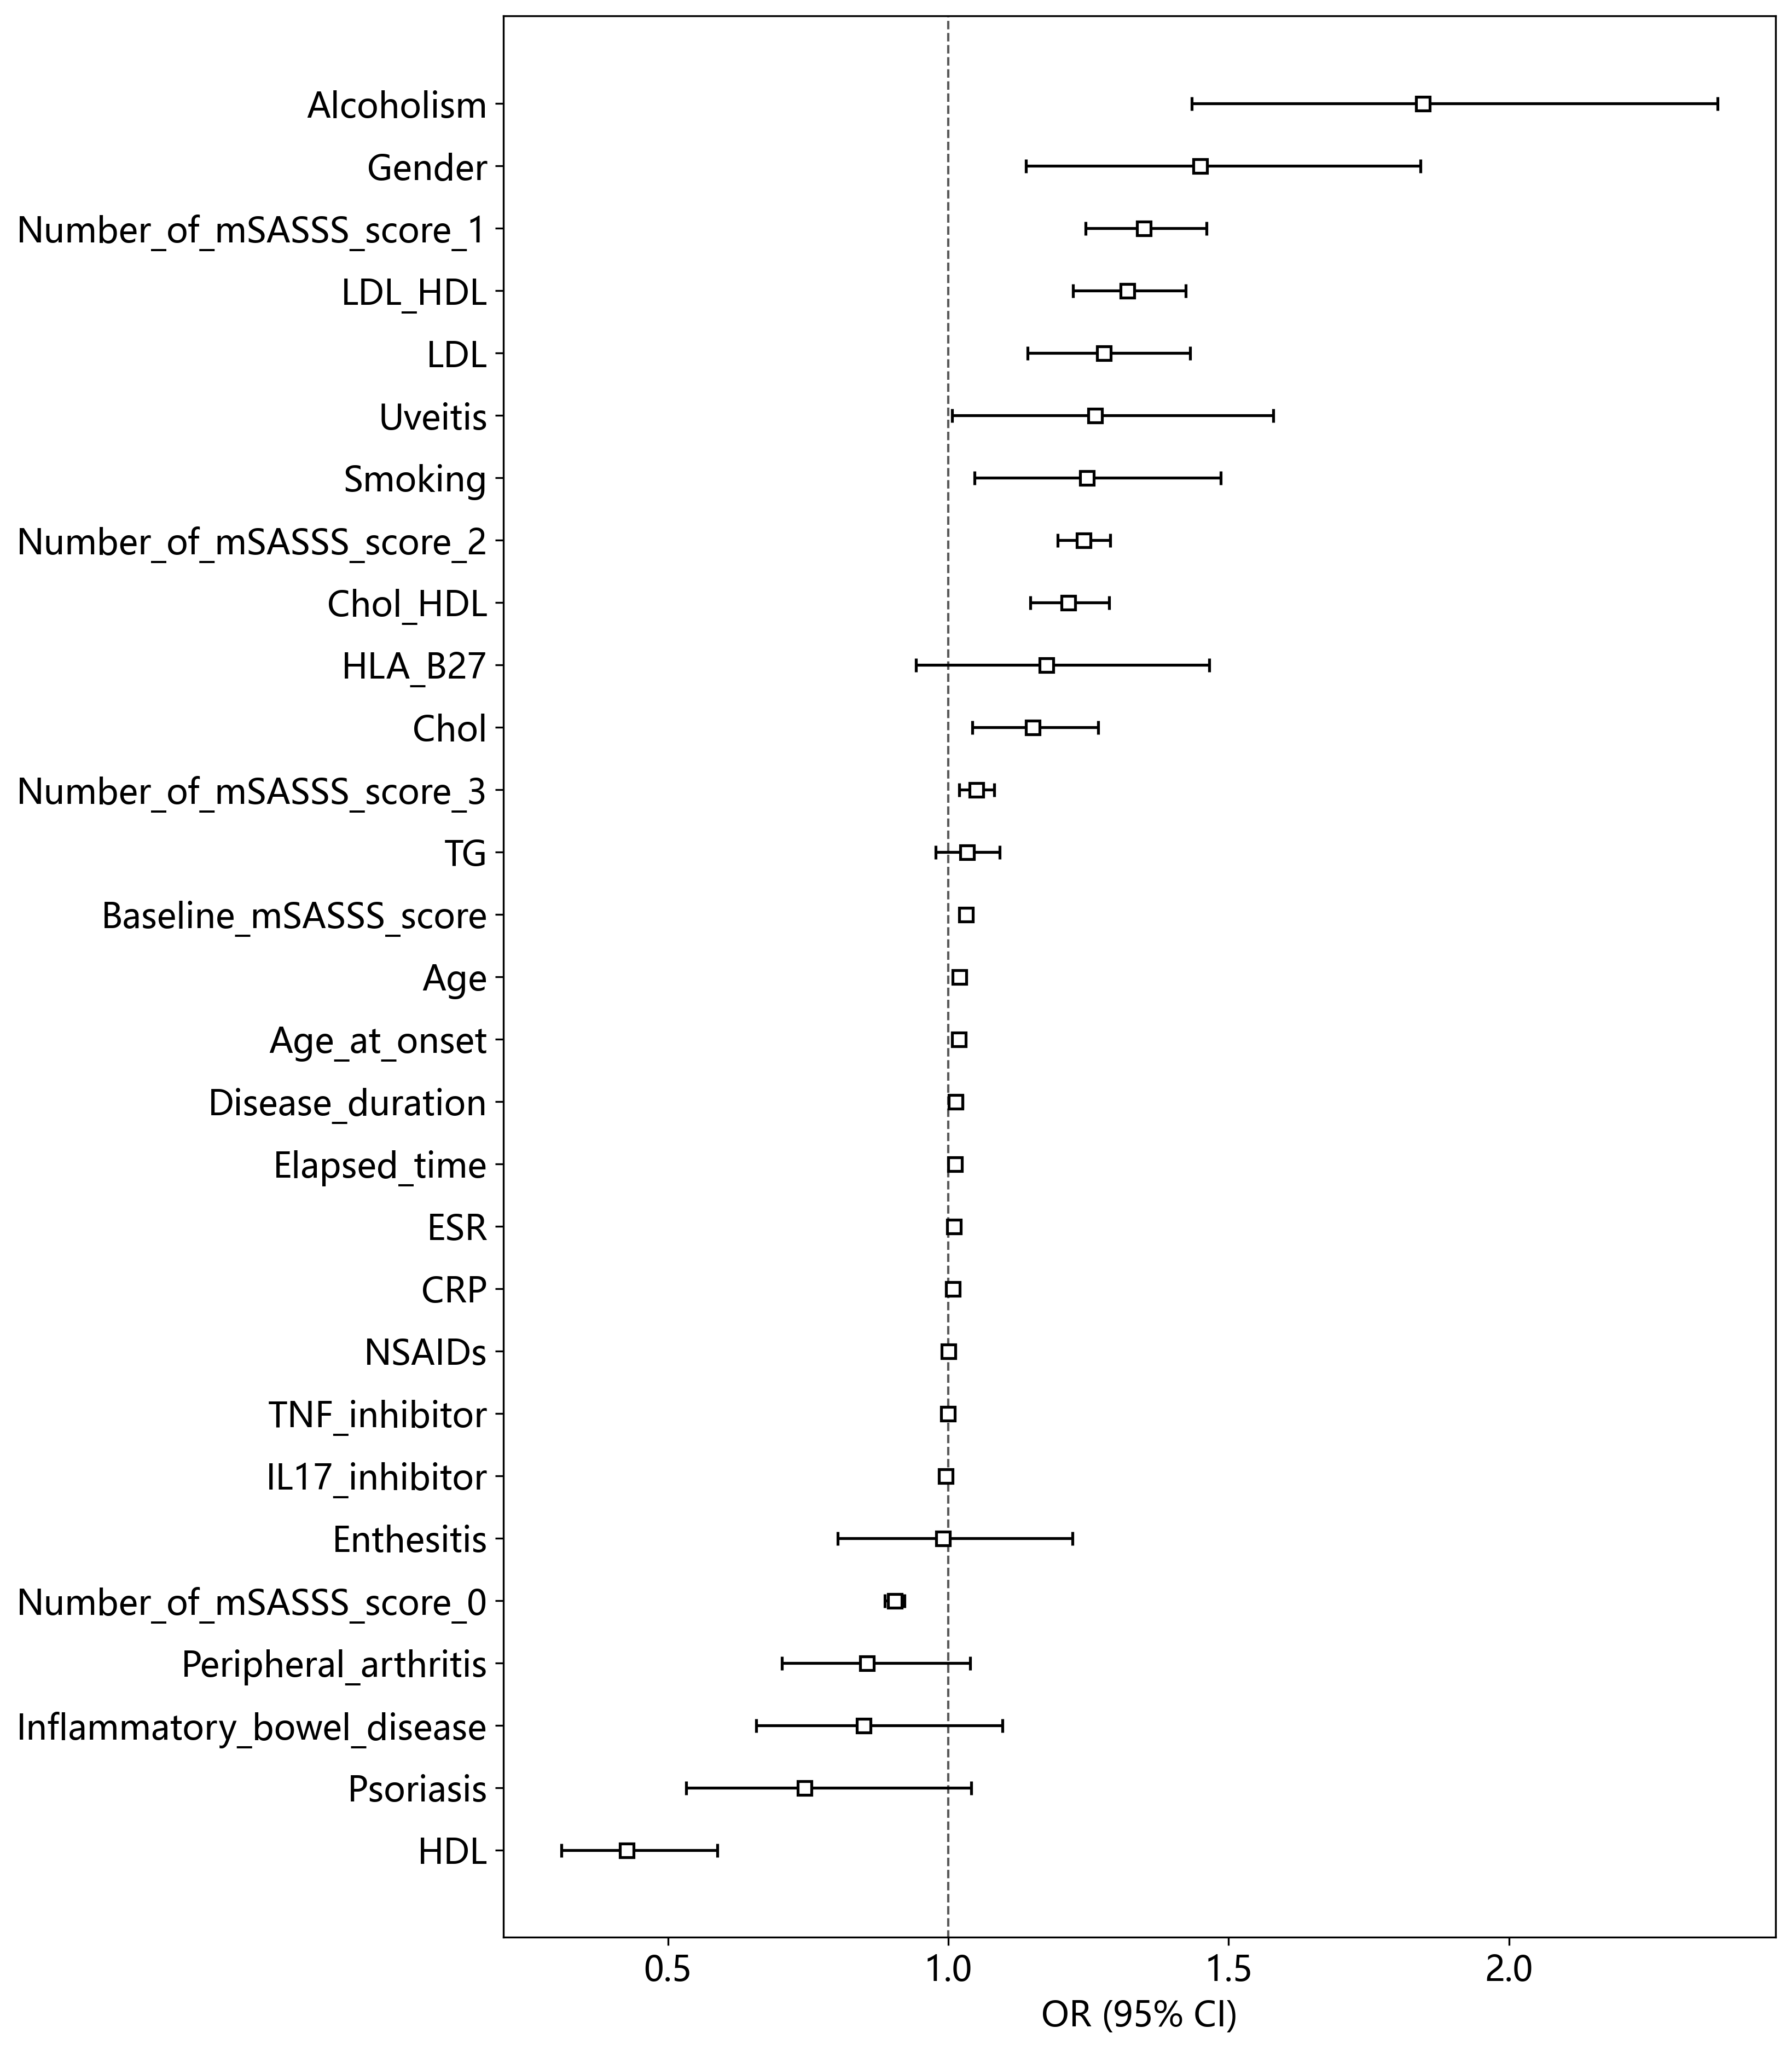

,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
HDL,-0.008,-0.662,0.647,0.993,0.516,1.910,0.985
Number_of_mSASSS_score_0,-0.071,-1.057,0.915,0.931,0.347,2.497,0.906
CRP,0.000,-0.003,0.004,1.000,0.997,1.004,0.846
ESR,0.005,0.002,0.009,1.005,1.002,1.009,0.016
Elapsed_time,0.008,0.006,0.011,1.008,1.006,1.011,0.000
Age_at_onset,0.011,0.000,0.021,1.011,1.000,1.021,0.084
Age,-0.011,-0.021,-0.000,0.989,0.979,1.000,0.090
Baseline_mSASSS_score,0.222,-0.171,0.614,1.248,0.843,1.848,0.352
Number_of_mSASSS_score_3,-0.703,-2.232,0.827,0.495,0.107,2.286,0.449


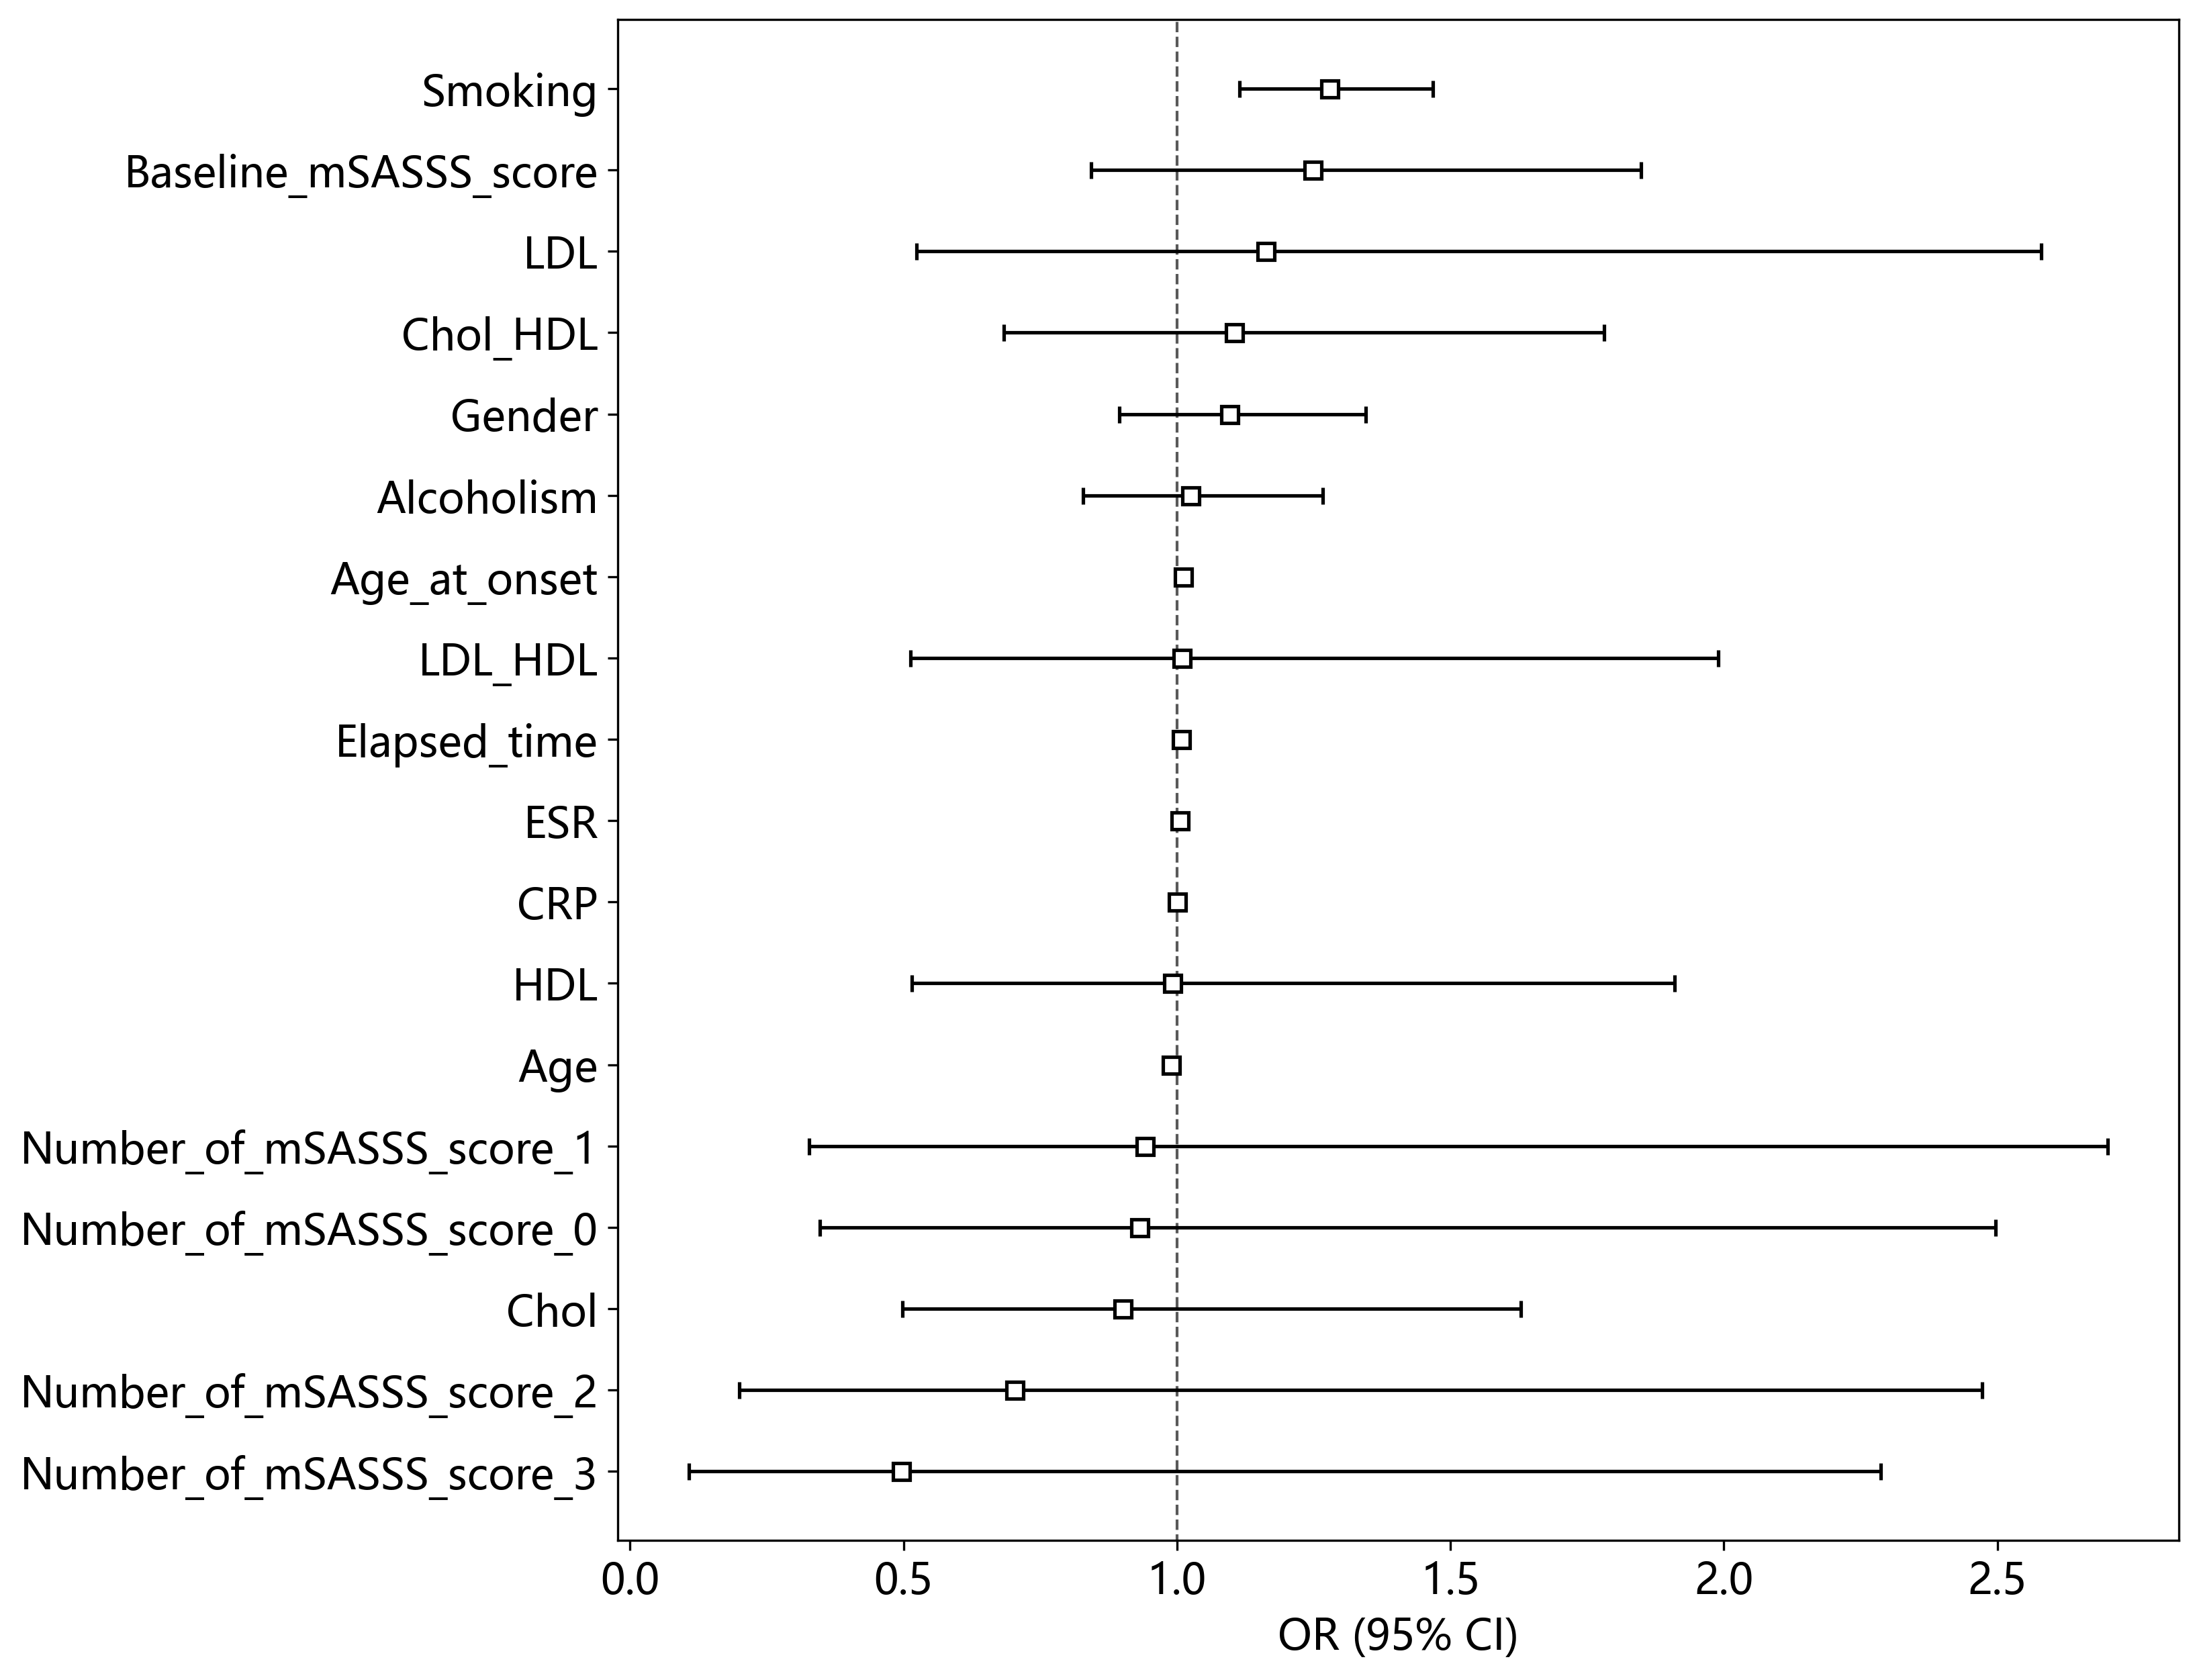

In [11]:
from onekey_algo.custom.components.comp1 import uni_multi_variable_analysis                        

r = uni_multi_variable_analysis(data[data['group'] != '1train'], stats_columns, save_dir='img', p_value4multi=p_value,
                                hazard_ratios=True, label_column=task, algo='ols')

In [12]:
uni_v = pd.read_csv('img/univariable_reg.csv')
uni_v = uni_v[uni_v['p_value'] <= 0.05]
sel_data = data[['ID'] + list(uni_v['feature_name']) + ['group', task]]
# sel_data = data[['ID'] + ['VBED80'] + ['group', task]]
sel_data.to_csv('data/clinic_sel.csv', index=False, encoding='utf-8-sig')
sel_data

,ID,HDL,Number_of_mSASSS_score_0,CRP,ESR,Elapsed_time,Age_at_onset,Age,Baseline_mSASSS_score,Number_of_mSASSS_score_3,...,Chol_HDL,Number_of_mSASSS_score_2,Smoking,LDL,LDL_HDL,Number_of_mSASSS_score_1,Gender,Alcoholism,group,label
0,白璨瑀202003-202501,0.93,11.0,24.60,54,57,9.0,19,2.0,0,...,3.903,1.0,0,2.14,2.301,0.0,1,0,train,0.000
1,边英杰202402-202502,1.19,5.5,2.50,8,12,28.0,38,11.0,0,...,2.933,4.5,0,1.90,1.597,2.0,0,0,train,0.000
2,常怀城201411-201709,0.76,11.5,3.45,4,33,27.0,29,0.5,0,...,4.000,0.0,1,1.97,2.592,0.5,1,0,train,0.916
3,陈博201803-202302,0.72,1.5,106.00,120,58,20.0,37,28.5,8,...,5.750,2.0,0,2.68,3.722,0.5,1,0,train,2.140
4,陈鹏202405-202505,1.05,11.0,13.00,22,12,26.0,28,2.0,0,...,4.105,1.0,0,2.66,2.533,0.0,1,0,val,0.000
5,陈巳稷201305-202404,0.74,7.5,12.10,8,130,20.0,30,6.5,0,...,4.649,2.0,1,2.32,3.135,2.5,1,0,train,2.996
6,陈曦201907-202303,1.07,11.5,3.13,28,44,21.0,26,0.5,0,...,4.327,0.0,1,3.11,2.907,0.5,1,0,val,1.504
7,程济民201311-202311,1.32,0.5,31.10,33,120,49.0,56,26.5,4,...,4.955,7.0,0,4.56,3.455,0.5,1,1,val,2.351
8,程济民201508-202311,0.42,0.0,98.00,62,99,49.0,58,29.5,6,...,12.524,5.5,0,3.51,8.357,0.5,1,1,train,2.015
9,程济民201611-202311,1.26,0.0,12.20,23,84,49.0,59,32.0,8,...,5.579,4.0,0,4.86,3.857,0.0,1,1,train,1.609


In [13]:
uni = pd.read_csv('img/univariable_reg.csv')
uni = uni[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
uni['95% CI'] = [f"{y:.4f}-{z:.4f}" for x, y, z in np.array(uni[[c for c in uni.columns if c not in ['feature_name', 'p_value']]])]
multi = pd.read_csv('img/multivariable_reg.csv')
multi = multi[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
multi['95% CI'] = [f"{y:.4f}-{z:.4f}" for x, y, z in np.array(multi[[c for c in multi.columns if c not in ['feature_name', 'p_value']]])]
info = pd.merge(uni[['feature_name', 'OR', '95% CI', 'p_value']], multi[['feature_name' , 'OR', '95% CI', 'p_value']],
                on='feature_name', how='left', suffixes=['_UNI', '_MULTI']).applymap(lambda x: '' if pd.isna(x) else x)
info.to_csv('results/uni_multi_analysis.csv', index=False, encoding='utf-8-sig')
info.applymap(lambda x: x if isinstance(x, str) or x > 0.05 else '<0.05')

,feature_name,OR_UNI,95% CI_UNI,p_value_UNI,OR_MULTI,95% CI_MULTI,p_value_MULTI
0,HDL,0.427,0.3100-0.5880,<0.05,0.993,0.5160-1.9100,0.985
1,Psoriasis,0.744,0.5320-1.0410,0.147,,,
2,Inflammatory_bowel_disease,0.849,0.6580-1.0960,0.291,,,
3,Peripheral_arthritis,0.855,0.7030-1.0390,0.184,,,
4,Number_of_mSASSS_score_0,0.904,0.8870-0.9220,<0.05,0.931,0.3470-2.4970,0.906
5,Enthesitis,0.990,0.8030-1.2210,0.939,,,
6,IL17_inhibitor,0.995,0.9840-1.0060,0.445,,,
7,TNF_inhibitor,0.999,0.9940-1.0040,0.796,,,
8,NSAIDs,1.001,0.9980-1.0030,0.707,,,
9,CRP,1.008,1.0040-1.0110,<0.05,1.0,0.9970-1.0040,0.846
